# MIDS DATASCI 207 Final Project True Sequence Models with PCA

## Imports

In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
from datetime import date
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.plotting import heatmap

import tulipy as ti

import sklearn
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.decomposition import KernelPCA
from sklearn.decomposition import IncrementalPCA

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras import initializers
import keras_tuner as kt
from keras_tuner import HyperParameters

import os
import sys
import warnings

# Data Loading and Initial Feature Engineering for LSTM Model

## Getting S&P500 Table Data

### Old method (risky since S&P500 Wikipedia might change randomly)

As of March 11, 2025, the last time a stock was added or removed from the S&P500 Wikipedia list was in December 2024. Therefore, for the extent of this project thus far, this shouldn't have affected us at all. However, we should keep a consistent csv of the stocks so we can have consistent GICS sectors (in case they change for some reason).

In [27]:
# Getting the S&P500 tables
sp500_tables = pd.read_html('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies')

In [26]:
# Getting the S&P500 list into a csv (only need to do once)
# df_sp500 = sp500_tables[0]
# df_sp500.to_csv('SP500_Tickers_March_2025.csv')

### Get S&P500 current list of stocks and their sectors using downloaded csv file

In [2]:
sp500_tables = pd.read_csv('SP500_Tickers_March_2025.csv', index_col='Unnamed: 0')
sp500_tables.head()

,Symbol,Security,GICS Sector,GICS Sub-Industry,Headquarters Location,Date added,CIK,Founded
0,MMM,3M,Industrials,Industrial Conglomerates,"Saint Paul, Minnesota",1957-03-04,66740,1902
1,AOS,A. O. Smith,Industrials,Building Products,"Milwaukee, Wisconsin",2017-07-26,91142,1916
2,ABT,Abbott Laboratories,Health Care,Health Care Equipment,"North Chicago, Illinois",1957-03-04,1800,1888
3,ABBV,AbbVie,Health Care,Biotechnology,"North Chicago, Illinois",2012-12-31,1551152,2013 (1888)
4,ACN,Accenture,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373,1989


## Loading in Data

In [3]:
# Loading in stock data
data = pd.read_csv("SP500_4y_day_data.csv", index_col='Date', parse_dates=True)

In [4]:
# Converting Date_col to datetime format
data['Date_col'] = pd.to_datetime(data['Date_col'])

In [5]:
data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank
Date,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0
...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0


## Feature Engineering
Outcome variables - Close price minus the Open price and variations of that

In [6]:
# Getting difference between close price and open price (outcome variables)
data["Close_Open_Diff"] = data["Close"] - data["Open"]
data["Close_Open_Diff_Perc"] = (data["Close"] - data["Open"]) / data["Open"] * 100

# Getting binary classification for whether a stock ended positive (1) or negative/zero (0)
data["Close_Open_Diff_Binary"] = data["Close_Open_Diff"] > 0

# Getting ternary classification for whether a stock ended positive (2), negative (0), or not much change (1)
close_open_conditions = [
    data['Close_Open_Diff_Perc'] > 0.5,       # Close price was at least 0.5% higher than Open price
    (data['Close_Open_Diff_Perc'] >= -0.5) &  # Close price was between -0.5% and 0.5% of Open price
        (data['Close_Open_Diff_Perc'] <= 0.5),
    data['Close_Open_Diff_Perc'] < -0.5       # Close price was at least 0.5% lower than Open price
]
close_open_choices = [2, 1, 0]  # Defining choices corresponding to conditions
data['Close_Open_Diff_Ternary'] = np.select(close_open_conditions, close_open_choices)  # Applying conditions

data

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,Close_Open_Diff_Binary,Close_Open_Diff_Ternary
Date,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,False,1
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,True,2
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,True,2
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,True,2
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,True,1
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-12-24,2024-12-24,ZTS,163.206597,164.542554,162.249499,164.203583,1023600.0,1001.0,0.996986,0.610874,True,2
2024-12-26,2024-12-26,ZTS,163.226540,165.290293,162.528653,165.021118,2167200.0,1002.0,1.794578,1.099440,True,2
2024-12-27,2024-12-27,ZTS,164.452833,166.028073,163.027150,164.103897,1800100.0,1003.0,-0.348936,-0.212180,False,1


Getting previous day metrics (since we don't know current day's metrics except open) and growth rates

In [7]:
# Getting the first actual trading day
first_trading_date = str(data.Date_col.idxmin().date())

# Getting growth rates and previous day OHLCV metrics
for x in data.columns[2:-6]:
  data[f'Growth Rate_{x}'] = (data[x] - data[x].shift(1))/data[x].shift(1) * 100
data["PDO"] = data["Open"].shift(1)
data["PDH"] = data["High"].shift(1)
data["PDL"] = data["Low"].shift(1)
data["PDC"] = data["Close"].shift(1)
data["PDV"] = data["Volume"].shift(1)

# For row in data, if date is first trading date, set above column values to null. Note: date is the index:
data.loc[first_trading_date, ['PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Growth Rate_Open', 'Growth Rate_High', 'Growth Rate_Low',
    'Growth Rate_Close']] = np.nan

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,Close_Open_Diff_Ternary,Growth Rate_Open,Growth Rate_High,Growth Rate_Low,Growth Rate_Close,PDO,PDH,PDL,PDC,PDV
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,2,-0.386760,0.191515,0.819730,0.817589,115.875028,116.995388,114.092184,115.582756,2030700.0
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,2,0.177242,2.958772,0.118571,2.742242,115.426870,117.219451,115.027432,116.527748,2344000.0
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,2,4.751879,2.906048,4.991124,2.660925,115.631454,120.687707,115.163820,119.723221,2428500.0
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,1,1.737320,0.125518,1.401992,0.713386,121.126122,124.194950,120.911790,122.908966,1775900.0


Getting gap (i.e., change from some previous day metric) features and volume features

In [8]:
# Getting the opening gap features from PDC
data["Gap_from_PDC"] = (data["Open"] - data["PDC"]) / data["PDC"]
gap_from_PDC_threshold = 0.02  # 2%
data["Gap_Binary_Threshold"] = abs(data["Gap_from_PDC"]) > gap_from_PDC_threshold

# Getting daily range gap up features
data["Daily_Range_Gap_Up"] = (data["Open"] - data["PDH"]) / data["PDH"]
data["Daily_Range_Gap_Up"] = data["Daily_Range_Gap_Up"].clip(lower = 0)
data["DR_Gap_Up_Binary"] = data["Daily_Range_Gap_Up"] > 0

# Getting daily range gap down features
data["Daily_Range_Gap_Down"] = (data["Open"] - data["PDL"]) / data["PDL"]
data["Daily_Range_Gap_Down"] = data["Daily_Range_Gap_Down"].clip(upper = 0)
data["DR_Gap_Down_Binary"] = data["Daily_Range_Gap_Down"] < 0

# Getting 14-day average volume and previous volume features
avg_vol_window = 14
data["Avg_Volume_14D"] = data["Volume"].rolling(window=avg_vol_window).mean()
data["Avg_Vol_Prev_14D"] = data["PDV"].rolling(window=avg_vol_window).mean()

# Comparing current volume to average volume over the past XX days
data["Vol_Change"] = (data["Volume"] - data["Avg_Vol_Prev_14D"]) / data["Avg_Vol_Prev_14D"]

# Setting the first 14-day volume averages and previous averages of every ticker to np.nan
data.loc[data["rank"] < 15, ["Avg_Volume_14D", "Avg_Vol_Prev_14D", "Vol_Change"]] = np.nan

data[10:20]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,PDV,Gap_from_PDC,Gap_Binary_Threshold,Daily_Range_Gap_Up,DR_Gap_Up_Binary,Daily_Range_Gap_Down,DR_Gap_Down_Binary,Avg_Volume_14D,Avg_Vol_Prev_14D,Vol_Change
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-19,2021-01-19,A,124.097539,124.506722,123.035631,124.068314,1677200.0,11.0,-0.029226,-0.023551,...,2115400.0,0.009270,False,0.002045,True,0.000000,False,NaN,NaN,NaN
2021-01-20,2021-01-20,A,124.419037,125.597856,124.078058,124.808731,1843000.0,12.0,0.389694,0.313211,...,1677200.0,0.002827,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-21,2021-01-21,A,124.477480,125.461455,123.162270,123.727325,1612100.0,13.0,-0.750155,-0.602643,...,1843000.0,-0.002654,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-22,2021-01-22,A,123.805281,124.506729,123.045382,123.074608,1438700.0,14.0,-0.730673,-0.590179,...,1612100.0,0.000630,False,0.000000,False,0.000000,False,NaN,NaN,NaN
2021-01-25,2021-01-25,A,123.425324,124.194968,121.223560,122.246506,1365400.0,15.0,-1.178819,-0.955086,...,1438700.0,0.002850,False,0.000000,False,0.000000,False,1.728993e+06,1.776514e+06,-0.231416
2021-01-26,2021-01-26,A,122.265994,122.704395,120.678000,120.726707,1476600.0,16.0,-1.539287,-1.258966,...,1365400.0,0.000159,False,0.000000,False,0.000000,False,1.667036e+06,1.728993e+06,-0.145977
2021-01-27,2021-01-27,A,118.934108,119.830399,115.066411,115.738632,1923500.0,17.0,-3.195476,-2.686762,...,1476600.0,-0.014848,False,0.000000,False,-0.014451,True,1.630964e+06,1.667036e+06,0.153845
2021-01-28,2021-01-28,A,115.933484,119.508910,115.719152,118.427513,1677900.0,18.0,2.494029,2.151258,...,1923500.0,0.001684,False,0.000000,False,0.000000,False,1.623964e+06,1.630964e+06,0.028778
2021-01-29,2021-01-29,A,118.086527,118.554161,116.206261,117.073326,1822000.0,19.0,-1.013201,-0.858016,...,1677900.0,-0.002879,False,0.000000,False,0.000000,False,1.641450e+06,1.623964e+06,0.121946


Getting technical and momentum indicators

In [9]:
# SMA and EMA including this period
data["SMA_14"] = data["Close"].rolling(window=14).mean()
data["SMA_50"] = data["Close"].rolling(window=50).mean()
data["SMA_200"] = data["Close"].rolling(window=200).mean()
data["EMA_9"] = data["Close"].ewm(span=9, adjust=False).mean()
data["EMA_20"] = data["Close"].ewm(span=20, adjust=False).mean()

# SMA and EMA for the past XXX periods
data["SMA_prev_14"] = data["PDC"].rolling(window=14).mean()
data["SMA_prev_50"] = data["PDC"].rolling(window=50).mean()
data["SMA_prev_200"] = data["PDC"].rolling(window=200).mean()
data["EMA_prev_9"] = data["PDC"].ewm(span=9, adjust=False).mean()
data["EMA_prev_20"] = data["PDC"].ewm(span=20, adjust=False).mean()

# RSI Calculation
delta = data["Close"].diff()
gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
rs = gain / loss
data["RSI_14"] = 100 - (100 / (1 + rs))

# RSI for the previous XX periods using tulipy
rsi_prev_14 = ti.rsi(data["PDC"].to_numpy(), 14)
nan_array_rsi = np.full(14, np.nan)
rsi_prev_14 = np.concatenate((nan_array_rsi, rsi_prev_14))
data["RSI_prev_14"] = rsi_prev_14

# ATR Calculation
data["ATR_14"] = (data["PDH"] - data["PDL"]).rolling(window=14).mean()
data["NATR_14"] = (data["ATR_14"] / data["PDC"]) * 100

# Setting 9, 14, 20, 50, and 200 day metrics to np.nan:
data.loc[data["rank"] <= 9, ['EMA_9', 'EMA_prev_9']] = np.nan
data.loc[data["rank"] <= 14, ['SMA_14', 'SMA_prev_14', 'RSI_14', 'RSI_prev_14', 'ATR_14', 'NATR_14']] = np.nan
data.loc[data["rank"] <= 20, ['EMA_20', 'EMA_prev_20']] = np.nan
data.loc[data["rank"] <= 50, ['SMA_50', 'SMA_prev_50']] = np.nan
data.loc[data["rank"] <= 200, ['SMA_200', 'SMA_prev_200']] = np.nan

data[:18]

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,EMA_20,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-11,2021-01-11,A,123.191505,126.007032,122.977180,124.847694,1746800.0,6.0,1.656190,1.344403,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-12,2021-01-12,A,125.023060,125.081511,122.947943,123.698105,1826400.0,7.0,-1.324955,-1.059768,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-13,2021-01-13,A,124.175467,124.750267,123.474019,123.707840,1530400.0,8.0,-0.467627,-0.376585,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2021-01-14,2021-01-14,A,123.990362,124.886660,122.577731,122.782318,924900.0,9.0,-1.208044,-0.974305,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
# Getting the sector for stocks as another feature
ticker_and_sector = sp500_tables[['Symbol', 'GICS Sector']]

# Getting the GICS sector into the table through a merge function
data = data.reset_index().merge(ticker_and_sector, left_on='Ticker', right_on='Symbol', how='left').set_index('Date')
data = data.drop(columns=['Symbol'])

# Replacing NaN GICS Sectors with Other
data['GICS Sector'] = data['GICS Sector'].fillna('Other')

data.head()

,Date_col,Ticker,Open,High,Low,Close,Volume,rank,Close_Open_Diff,Close_Open_Diff_Perc,...,SMA_prev_14,SMA_prev_50,SMA_prev_200,EMA_prev_9,EMA_prev_20,RSI_14,RSI_prev_14,ATR_14,NATR_14,GICS Sector
Date,,,,,,,,,,,,,,,,,,,,,
2021-01-04,2021-01-04,A,115.875028,116.995388,114.092184,115.582756,2030700.0,1.0,-0.292272,-0.252231,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-05,2021-01-05,A,115.426870,117.219451,115.027432,116.527748,2344000.0,2.0,1.100878,0.953745,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-06,2021-01-06,A,115.631454,120.687707,115.163820,119.723221,2428500.0,3.0,4.091766,3.538627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-07,2021-01-07,A,121.126122,124.194950,120.911790,122.908966,1775900.0,4.0,1.782844,1.471891,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care
2021-01-08,2021-01-08,A,123.230471,124.350838,122.606963,123.785782,1577200.0,5.0,0.555311,0.450628,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Health Care


In [11]:
# Getting date index column:
date_index = data.index.sort_values()

# Dropping duplicates:
date_index = date_index.drop_duplicates()

date_index

DatetimeIndex(['2021-01-04', '2021-01-05', '2021-01-06', '2021-01-07',
               '2021-01-08', '2021-01-11', '2021-01-12', '2021-01-13',
               '2021-01-14', '2021-01-15',
               ...
               '2024-12-17', '2024-12-18', '2024-12-19', '2024-12-20',
               '2024-12-23', '2024-12-24', '2024-12-26', '2024-12-27',
               '2024-12-30', '2024-12-31'],
              dtype='datetime64[ns]', name='Date', length=1005, freq=None)

## Selecting Base Features

In [12]:
data.columns

Index(['Date_col', 'Ticker', 'Open', 'High', 'Low', 'Close', 'Volume', 'rank',
       'Close_Open_Diff', 'Close_Open_Diff_Perc', 'Close_Open_Diff_Binary',
       'Close_Open_Diff_Ternary', 'Growth Rate_Open', 'Growth Rate_High',
       'Growth Rate_Low', 'Growth Rate_Close', 'PDO', 'PDH', 'PDL', 'PDC',
       'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold', 'Daily_Range_Gap_Up',
       'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary',
       'Avg_Volume_14D', 'Avg_Vol_Prev_14D', 'Vol_Change', 'SMA_14', 'SMA_50',
       'SMA_200', 'EMA_9', 'EMA_20', 'SMA_prev_14', 'SMA_prev_50',
       'SMA_prev_200', 'EMA_prev_9', 'EMA_prev_20', 'RSI_14', 'RSI_prev_14',
       'ATR_14', 'NATR_14', 'GICS Sector'],
      dtype='object')

In [13]:
# Getting a copy of the data to work with so we don't ruin original
data_small = data.copy()

# Removing BIIB ticker in general (since it's missing data for one of the trading days)
data_small = data_small[data_small['Ticker'] != 'BIIB']

# If rank is less than or equal to the number of NA_days, drop the row (since there will be NaN data)
NA_days = 50  # Choosing 50 for SMA_prev_50
data_small = data_small[data_small['rank'] > NA_days]

# Only keeping certain columns
data_small_columns_keep = ['Date_col', 'Ticker', 'Open', 'PDO', 'PDH', 'PDL', 'PDC', 'PDV', 'Gap_from_PDC', 'Gap_Binary_Threshold',
    'Daily_Range_Gap_Up', 'DR_Gap_Up_Binary', 'Daily_Range_Gap_Down', 'DR_Gap_Down_Binary', 'Avg_Vol_Prev_14D', 'Vol_Change',
    'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20', 'RSI_prev_14', 'NATR_14', 'GICS Sector', 'Close_Open_Diff_Perc',
    'Close_Open_Diff_Ternary']

data_small = data_small[data_small_columns_keep]

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,4.536250e+05,453625.000000,453625.000000,453625.000000,4.536250e+05,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078533888,167.796289,167.735657,169.605319,165.838671,167.744599,5.939897e+06,0.000309,0.001013,-0.000990,5.951962e+06,0.023919,167.312294,165.962688,167.479749,167.087536,51.783003,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,1.010000,1.010000,1.040000,0.780000,0.980000,6.300000e+03,-0.388039,0.000000,-0.386389,1.150000e+04,-0.915551,1.055000,1.203000,1.059442,1.095938,3.203542,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,51.142663,51.130001,51.703654,50.546797,51.130585,9.969000e+05,-0.003835,0.000000,0.000000,1.094914e+06,-0.263134,51.035951,50.821200,51.097153,51.034005,43.036001,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,97.997940,97.980003,99.150002,96.781114,97.964836,2.042700e+06,0.000411,0.000000,0.000000,2.154914e+06,-0.083369,97.879983,97.531522,97.929508,97.831366,51.785360,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,187.732867,187.665114,189.720001,185.619995,187.674515,4.692700e+06,0.004637,0.000000,0.000000,4.816121e+06,0.161837,187.518051,186.307378,187.644120,187.424250,60.554521,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,9914.169922,9914.169922,9964.769531,9794.000000,9924.400391,1.543911e+09,0.536680,0.391608,0.000000,7.066849e+08,25.587868,9677.040737,9442.719980,9744.845871,9637.574378,96.316095,18.195811,32.653064,2.000000
std,NaN,354.722275,354.475111,358.475832,350.625212,354.573813,2.411370e+07,0.011125,0.004844,0.005323,2.313540e+07,0.534852,352.761797,347.020647,353.412287,351.684981,12.172738,0.911041,1.619073,0.828860


In [14]:
# Getting some percent changes for the PDC compared to PDO for the first 5 values of data_small
data_small.iloc[0:5]['PDC'] / data_small.iloc[0:5]['PDO']
# These values will be a good litmus test to confirm that our normalization kept our percent differences between price values

Date
2021-03-17    0.985972
2021-03-18    1.001471
2021-03-19    0.991828
2021-03-22    0.998535
2021-03-23    1.011787
dtype: float64

In [15]:
# Doing the same, but for volume
data_small.iloc[0:5]['PDV'] / data_small.iloc[0:5]['Avg_Vol_Prev_14D']

Date
2021-03-17    0.737364
2021-03-18    0.795588
2021-03-19    1.125113
2021-03-22    1.350650
2021-03-23    0.905052
dtype: float64

In [16]:
# Defining a function to normalize the prices/volume to the max (*2) of every ticker
def normalize_to_max_per_ticker(df, col_list):
    df_normalized = df.copy()

    # Grouping by Ticker and getting the max values for either price or volume by ticker
    max_vals = df_normalized.groupby('Ticker')[col_list].transform('max').max(axis=1)

    # Applying normalization to entire df by dividing by max values for each ticker and then multiplying by 2
    df_normalized[col_list] = df_normalized[col_list].div(max_vals, axis=0) * 2

    return df_normalized

# Note: We normalize to the maximum (instead of using MinMax) of each ticker in order to preserve the same % changes as the unnormalized
# value. In our case, our normalized maximum will be 2, so our values will range from (down to) 0 to 2

In [17]:
# Normalizing the following columns to the global maximum prices (by percent compared to max price) for each ticker 
# ^e.g., if OHLC for a day is 2, 3, 1, 4, respectively, then their normalized versions would be 1, 1.5, 0.5, 2, respectively for that day
price_cols_to_norm = ['Open', 'PDO', 'PDH', 'PDL', 'PDC', 'SMA_prev_14', 'SMA_prev_50', 'EMA_prev_9', 'EMA_prev_20']
data_small = normalize_to_max_per_ticker(data_small, price_cols_to_norm)

# Normalizing volumes for all dates to the global maximum volume (by percent compared to max volume) for each ticker
volume_cols_to_norm = ['PDV', 'Avg_Vol_Prev_14D']
data_small = normalize_to_max_per_ticker(data_small, volume_cols_to_norm)

# Normalizing the following columns as percent (currently these are decimal changes) (except Vol_Change)
cols_to_perc = ['Gap_from_PDC', 'Daily_Range_Gap_Up', 'Daily_Range_Gap_Down']
data_small.loc[:, cols_to_perc] = data_small.loc[:, cols_to_perc] * 100

# Normalizing RSI to be between 0 and 1
data_small.loc[:, ['RSI_prev_14']] = data_small.loc[:, ['RSI_prev_14']] / 100

data_small.describe()

,Date_col,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Daily_Range_Gap_Up,Daily_Range_Gap_Down,Avg_Vol_Prev_14D,Vol_Change,SMA_prev_14,SMA_prev_50,EMA_prev_9,EMA_prev_20,RSI_prev_14,NATR_14,Close_Open_Diff_Perc,Close_Open_Diff_Ternary
count,453625,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000,453625.000000
mean,2023-02-06 10:24:15.078533888,1.352334,1.352055,1.367110,1.336596,1.351941,0.331648,0.030902,0.101300,-0.098990,0.332086,0.023919,1.349815,1.342335,1.350641,1.348760,0.517830,2.362572,0.008622,1.011241
min,2021-03-17 00:00:00,0.053784,0.053784,0.056452,0.052552,0.053707,0.008487,-38.803893,0.000000,-38.638898,0.013925,-0.915551,0.063100,0.073716,0.060571,0.069261,0.032035,0.212823,-50.071084,0.000000
25%,2022-02-24 00:00:00,1.126022,1.125793,1.140061,1.112043,1.126120,0.181249,-0.383452,0.000000,0.000000,0.206541,-0.263134,1.125616,1.122068,1.126414,1.126401,0.430360,1.748904,-0.845422,0.000000
50%,2023-02-07 00:00:00,1.391997,1.391661,1.407153,1.375842,1.391571,0.287909,0.041106,0.000000,0.000000,0.315782,-0.083369,1.389664,1.383033,1.390428,1.389124,0.517854,2.163510,0.025686,1.000000
75%,2024-01-22 00:00:00,1.615531,1.615151,1.631728,1.597817,1.614908,0.424620,0.463727,0.000000,0.000000,0.437228,0.161837,1.611993,1.602763,1.613052,1.610022,0.605545,2.738881,0.871954,2.000000
max,2024-12-31 00:00:00,2.000000,2.000000,2.000000,1.991389,1.999860,2.000000,53.667959,39.160845,0.000000,1.396082,25.587868,1.993995,2.000000,1.994551,2.000000,0.963161,18.195811,32.653064,2.000000
std,NaN,0.345995,0.345914,0.347798,0.343587,0.345700,0.222903,1.112548,0.484430,0.532302,0.169022,0.534852,0.343052,0.335889,0.343385,0.340425,0.121727,0.911041,1.619073,0.828860


In [18]:
# Double checking data_small shows us that we do indeed keep % differences between price features on the same day even after normalization
data_small.iloc[0:5]['PDC'] / data_small.iloc[0:5]['PDO']

Date
2021-03-17    0.985972
2021-03-18    1.001471
2021-03-19    0.991828
2021-03-22    0.998535
2021-03-23    1.011787
dtype: float64

In [19]:
# And we see that we also keep % differences between the two volume features on the same day after normalization
data_small.iloc[0:5]['PDV'] / data_small.iloc[0:5]['Avg_Vol_Prev_14D']

Date
2021-03-17    0.737364
2021-03-18    0.795588
2021-03-19    1.125113
2021-03-22    1.350650
2021-03-23    0.905052
dtype: float64

In [20]:
# Ordering by date, and then by ticker to get the right splits for train/val/test
data_small = data_small.sort_values(by=['Date_col', 'Ticker'])

# LSTM Model Testing Using PCA
The idea behind using PCA is that we have a lot of different features, many of which are highly correlated. Therefore, PCA might be a good way to reduce that number (and subsequently the noise), which might improve the generalizability of our model. It also might make our model run a bit faster (though with LSTM models, the main bottleneck is with the number cell parameters themselves (i.e., the number of LSTM units)).

## Creating dummy variables for GICS Sector

In [24]:
# Getting a copy of data_small called data_smaller
data_smaller = data_small.copy()

In [25]:
# Getting dummy variables for GICS Sector
sector_dummy = pd.get_dummies(
    data_smaller['GICS Sector'],
    drop_first = False
)
print("Number of data_smaller dummy variables:", data_smaller['GICS Sector'].nunique())
print("Shape of data_smaller dummy variable for GICS Sector:",
      sector_dummy.shape, '\n')

# Adding the dummy variables to data_smaller
data_smaller = pd.concat(
    [data_smaller, sector_dummy],
    axis=1
)

Number of data_smaller dummy variables: 12
Shape of data_smaller dummy variable for GICS Sector: (453625, 12) 



In [26]:
# Checking to make sure dummies were created correctly
data_smaller.head(3)

,Date_col,Ticker,Open,PDO,PDH,PDL,PDC,PDV,Gap_from_PDC,Gap_Binary_Threshold,...,Consumer Staples,Energy,Financials,Health Care,Industrials,Information Technology,Materials,Other,Real Estate,Utilities
Date,,,,,,,,,,,,,,,,,,,,,
2021-03-17,2021-03-17,A,1.358732,1.385498,1.391718,1.359954,1.366062,0.274100,-0.536577,False,...,False,False,False,True,False,False,False,False,False,False
2021-03-17,2021-03-17,AAL,1.848984,1.924875,1.935608,1.863549,1.875814,0.577977,-1.430317,False,...,False,False,False,False,False,False,False,True,False,False
2021-03-17,2021-03-17,AAP,1.455625,1.470280,1.472615,1.427039,1.442258,0.090444,0.926817,False,...,False,False,False,False,False,False,False,True,False,False


In [27]:
# Removing GICS Sector since we've converted it to one-hot encoding
data_smaller = data_smaller.drop("GICS Sector", axis = 1)

print("Shape of data_smaller after removing original GICS Sector feature:",
      data_smaller.shape)

Shape of data_smaller after removing original GICS Sector feature: (453625, 36)


## Function for Creating Sequences for LSTM Model

In [28]:
# Function for creating sequences for LSTM model
def create_sequences_grouped(df, seq_length, group_col, target_col, drop_cols):
    """Create LSTM sequences separately for each unique ticker in the dataset."""
    X, Y = [], []
    
    # Group data by unique time series identifier (i.e., 'Ticker')
    grouped = df.groupby(group_col)
    
    for _, group in grouped:
        # Sorting by Date_col and removing the 'Ticker' column and dropped columns
        group = group.sort_values(by='Date_col')
        group = group.drop(columns=drop_cols)
        group = group.drop(columns=[group_col])

        # Getting feature and label columns
        feature_cols = group.drop(columns=[target_col]).columns
        feature_data = group[feature_cols].values
        labels = group[target_col].values
        
        # Creating sequences for this group only
        for i in range(len(group) - seq_length + 1):
            X.append(feature_data[i:i+seq_length])  # Collecting seq_length time steps
            Y.append(labels[i+seq_length-1])   # Target label is the most recent time step

    # Converting dtypes to the correct dtype
    X = np.array(X)
    X = X.astype(np.float32)
    Y = np.array(Y)
    Y = Y.astype(np.int32)
    
    return X, Y

## LSTM Classfication with PCA (all stocks, smaller test and validation data sizes)

### Generating X continuous series sequences, Y continuous labels, and splitting data into train and test sets
This is the exact same process as the very first LSTM model with the 99/1 train/test split

In [29]:
# Creating sequences for LSTM model
seq_length = 14
group_col = 'Ticker'
target_col = 'Close_Open_Diff_Ternary'
drop_cols = ['Date_col', 'Close_Open_Diff_Perc']

X_data_smaller, Y_data_smaller = create_sequences_grouped(data_smaller, seq_length, group_col, target_col, drop_cols)

In [30]:
# Confirming shapes
print('Shape of X_data_smaller:', X_data_smaller.shape)
print('Shape of Y_data_smaller:', Y_data_smaller.shape, '\n')

# Confirming that we should have the correct number of sequences in X_data_smaller
unique_tickers = data_smaller['Ticker'].nunique()
unique_dates = data_smaller['Date_col'].nunique()
expected_num_sequences = unique_tickers * (unique_dates - seq_length + 1)

print('Number of unique tickers in data_smaller:', unique_tickers)
print('Number of unique dates in data_smaller:', unique_dates)
print('Chosen sequence length:', seq_length)
print('Number of sequences assuming the above seq_length:', unique_dates - seq_length + 1, '\n')

print('Total number of data sequences expected:', expected_num_sequences)
print('Total number of data sequences achieved:', X_data_smaller.shape[0])

Shape of X_data_smaller: (447450, 14, 32)
Shape of Y_data_smaller: (447450,) 

Number of unique tickers in data_smaller: 475
Number of unique dates in data_smaller: 955
Chosen sequence length: 14
Number of sequences assuming the above seq_length: 942 

Total number of data sequences expected: 447450
Total number of data sequences achieved: 447450


In [31]:
# Getting the number of sequences per ticker (same calculation as above, but now defined in a variable)
num_sequences_per_ticker = unique_dates - seq_length + 1

# Splitting the data into train and test sets
num_train_seq_int = int(0.99 * num_sequences_per_ticker)
train_size = num_train_seq_int * unique_tickers

X_train = X_data_smaller[:train_size]
Y_train = Y_data_smaller[:train_size]
X_test = X_data_smaller[train_size:]
Y_test = Y_data_smaller[train_size:]

# Confirming shapes
print('Shape of X_train:', X_train.shape)
print('Shape of Y_train:', Y_train.shape)
print('Shape of X_test:', X_test.shape)
print('Shape of Y_test:', Y_test.shape, '\n')

# Confirming number of dates
print('Number of dates in X_train:', num_train_seq_int)
print('Number of dates in X_test:', num_sequences_per_ticker - num_train_seq_int)

Shape of X_train: (442700, 14, 32)
Shape of Y_train: (442700,)
Shape of X_test: (4750, 14, 32)
Shape of Y_test: (4750,) 

Number of dates in X_train: 932
Number of dates in X_test: 10


### Standardizing the features

In [41]:
# Reshaping the data from all sequences as independent examples (ignoring order for now so we can perform PCA)
X_train_2D = X_train.reshape(-1, X_train.shape[2])
X_test_2D = X_test.reshape(-1, X_test.shape[2])

# Standardizing the features (i.e., learning the  mean and variance from the train data, then using these values to standardize both the
# train and test data)
sc = StandardScaler()
sc.fit(X_train_2D)

StandardScaler()

In [52]:
# Checking out the mean and variances of the data in X_train_2D
print("Mean: ", sc.mean_, '\nVariance: ', sc.var_)

# Transforming X_train and X_test
X_train_std = sc.transform(X_train_2D)
X_test_std = sc.transform(X_test_2D)

Mean:  [ 1.35072301  1.35039846  1.36542593  1.33496418  1.35029062  0.33137011
  0.03368043  0.04761657  0.10219116  0.16217626 -0.0990017   0.13152909
  0.3315979   0.02459294  1.34797086  1.34054214  1.3488713   1.34683231
  0.51834202  2.35848647  0.04468489  0.09362548  0.07234696  0.04042918
  0.13831037  0.10852044  0.14673142  0.10852044  0.05532415  0.07660267
  0.057452    0.057452  ] 
Variance:  [0.11942159 0.11934852 0.12065069 0.11774489 0.11919992 0.04934528
 1.24071663 0.04534924 0.23737275 0.13587512 0.2839492  0.11422919
 0.02851952 0.28253194 0.11723992 0.11228527 0.11753425 0.11544328
 0.01482744 0.82200939 0.04268815 0.08485975 0.06711288 0.03879467
 0.11918061 0.09674376 0.12520131 0.09674376 0.05226339 0.0707347
 0.05415127 0.05415127]


### (Manual) Getting the eigenvalues and eigenvectors, constructing the projection matrix, and transforming the original dataset

In [54]:
# Constructing the covariance matrix
cov_matrix = np.cov(X_train_std.T)
pd.DataFrame(cov_matrix).head()

,0,1,2,3,4,5,6,7,8,9,...,22,23,24,25,26,27,28,29,30,31
0,1.000000,0.997377,0.998299,0.998417,0.999169,-0.051622,0.032982,-0.103556,-0.030038,0.010966,...,0.117651,-0.035353,-0.012105,0.079665,-0.000163,-0.051043,0.049124,-0.204086,0.066402,0.126904
1,0.997377,1.000000,0.999219,0.999068,0.998203,-0.051215,-0.005779,-0.101119,-0.059012,-0.021985,...,0.117859,-0.035617,-0.012348,0.079788,-0.000431,-0.051284,0.049297,-0.203465,0.066437,0.126894
2,0.998299,0.999219,1.000000,0.998889,0.999123,-0.045665,-0.005623,-0.098455,-0.056173,-0.017869,...,0.116070,-0.034079,-0.013127,0.079579,-0.001824,-0.050715,0.049909,-0.200864,0.066150,0.125383
3,0.998417,0.999068,0.998889,1.000000,0.999228,-0.057957,-0.005480,-0.105081,-0.056958,-0.015312,...,0.119784,-0.037303,-0.011418,0.080048,0.000867,-0.051794,0.048621,-0.206311,0.066452,0.128284
4,0.999169,0.998203,0.999123,0.999228,1.000000,-0.052104,-0.005823,-0.102488,-0.051815,-0.006210,...,0.117888,-0.035698,-0.012299,0.080004,-0.000393,-0.051081,0.049237,-0.203944,0.066372,0.126910


In [63]:
# Getting our eigenvalues and eigenvectors
eigen_values, eigen_vectors = np.linalg.eigh(cov_matrix)

# Computing the explained variance ratio
sum_eigen_values = sum(eigen_values)
print('Sum eigenvalues: ', sum_eigen_values)

# Seeing how much variance the eigenvalues explain
expl_var_ratio = [i/sum_eigen_values for i in sorted(eigen_values, reverse=True)]
print('\nExplained variance ratio and its cumsum:')
pd.DataFrame([expl_var_ratio, np.cumsum(expl_var_ratio)]).T

Sum eigenvalues:  32.00000502650356

Explained variance ratio and its cumsum:


,0,1
0,2.901039e-01,0.290104
1,7.666886e-02,0.366773
2,6.277034e-02,0.429543
3,6.076867e-02,0.490312
4,4.073538e-02,0.531047
5,3.640726e-02,0.567454
6,3.531284e-02,0.602767
7,3.486993e-02,0.637637
8,3.424231e-02,0.671880
9,3.407389e-02,0.705953


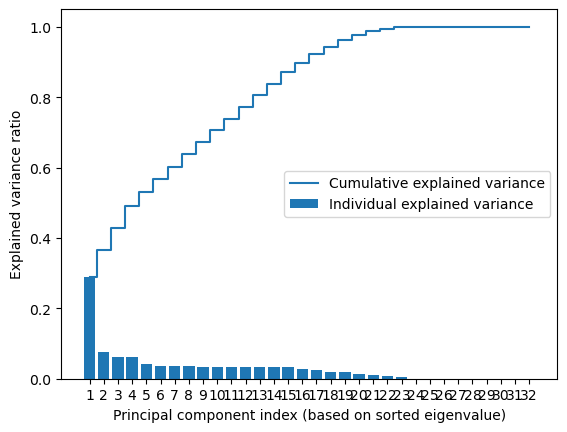

In [58]:
# Visualizing the explained variance ratio and the cumulative explained variance ratio
x_axis = range(1,len(eigen_values)+1)
y_axis = expl_var_ratio

# Plotting the individual ratio
plt.bar(x_axis, y_axis, label='Individual explained variance')
# plot cumulative ratio
plt.step(x_axis, np.cumsum(y_axis), where='mid', label='Cumulative explained variance')
plt.legend()
plt.xticks(x_axis)
plt.ylabel('Explained variance ratio');
plt.xlabel('Principal component index (based on sorted eigenvalue)')
plt.show()

In [59]:
# Creating eigen pairs of vectors and values
eigen_pairs = [(eigen_values[i], eigen_vectors[:,i]) for i in range(len(eigen_vectors))]

# Transforming into dataframe
eigen_pairs = pd.DataFrame(eigen_pairs)
eigen_pairs.rename(columns={0: 'eigen_value', 1: 'eigen_vector'}, inplace=True)
eigen_pairs.head()

,eigen_value,eigen_vector
0,2.991355e-13,"[0.0, 1.910996900981079e-12, -2.34009709192562..."
1,7.179046e-05,"[-0.6368966141166136, 0.0739177890976824, -0.0..."
2,2.232575e-04,"[-0.38936310351276854, -0.5113255685654783, 0...."
3,2.793335e-04,"[-0.07567257521556124, -0.04832390557355322, 0..."
4,3.196706e-04,"[-0.09743591037277236, -0.03714238013387847, 0..."


In [67]:
# Select the top 13 eigenvectors based on the eigenvalue (explaining 80% of the variance)
top13_eigen_vectors = eigen_pairs.nlargest(13, 'eigen_value')['eigen_vector'].values.tolist()

In [69]:
# Getting the projection matrix, w
w = np.hstack((top13_eigen_vectors[0][:, np.newaxis],
               top13_eigen_vectors[1][:, np.newaxis],
               top13_eigen_vectors[2][:, np.newaxis],
               top13_eigen_vectors[3][:, np.newaxis],
               top13_eigen_vectors[4][:, np.newaxis],
               top13_eigen_vectors[5][:, np.newaxis],
               top13_eigen_vectors[6][:, np.newaxis],
               top13_eigen_vectors[7][:, np.newaxis],
               top13_eigen_vectors[8][:, np.newaxis],
               top13_eigen_vectors[9][:, np.newaxis],
               top13_eigen_vectors[10][:, np.newaxis],
               top13_eigen_vectors[11][:, np.newaxis],
               top13_eigen_vectors[12][:, np.newaxis]
              ))
print('\nSize of Matrix W: ', w.shape)


Size of Matrix W:  (32, 13)


In [70]:
# Transforming the original input dataset, X_train_std, using the projection matrix, w
X_train_pca = X_train_std.dot(w)
pd.DataFrame(X_train_pca).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.172224,1.522982,-0.093792,0.240096,0.499148,-0.104810,0.208474,2.694617,0.763544,0.526072,-0.265098,-0.108781,-0.084068
1,0.136545,-1.635578,0.693071,-0.646594,0.231149,-0.044355,0.290881,2.856244,0.760161,0.294094,-0.108473,-0.081175,-0.017089
2,0.196548,-0.040496,0.178940,0.491590,0.531675,-0.032269,0.384520,2.911049,0.630856,0.150756,-0.068369,-0.003309,0.126101
3,0.168377,0.140375,0.142048,1.038509,0.680930,-0.078838,0.315025,2.821028,0.659039,0.296008,-0.157740,-0.026583,0.052153
4,0.224329,0.039278,-0.334686,0.882188,0.567847,-0.095157,0.203694,2.753482,0.788675,0.413259,-0.197730,-0.076906,-0.064722


In [72]:
# Doing it for the test data as well
X_test_pca = X_test_std.dot(w)
pd.DataFrame(X_test_pca).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,4.730794,-0.039211,-1.190290,-0.677538,-1.157406,2.135694,0.426828,-0.460474,0.139918,0.729134,-0.384497,-0.099884,0.224286
1,4.762902,-0.005650,-1.056947,-0.766601,-1.323856,2.144932,0.418005,-0.423320,0.177868,0.679963,-0.321479,-0.107889,0.214582
2,4.644909,-0.074203,-1.074370,-0.651271,-0.826319,2.154821,0.566375,-0.433921,-0.051170,0.657773,-0.433401,-0.032495,0.372336
3,4.528060,0.117860,-1.342183,-0.448149,-0.643800,2.136340,0.550970,-0.495102,-0.077279,0.744455,-0.525221,-0.031681,0.357310
4,4.330091,2.183236,-0.621610,-1.185275,-0.824927,2.157215,0.653786,-0.455133,-0.203788,0.694060,-0.533485,-0.016321,0.436314


### (Scikit-learn) Doing it in scikit-learn just to confirm we get the same results

In [85]:
# Fitting PCA to X_train_std
pca = PCA(n_components=13)
X_train_pca_sk = pca.fit_transform(X_train_std)
pd.DataFrame(X_train_pca_sk).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,0.172535,-1.522712,-0.092941,0.241666,-0.497273,-0.105130,-0.208759,2.695101,0.764482,-0.521831,-0.260760,0.108863,0.083116
1,0.136856,1.635866,0.693842,-0.645061,-0.229297,-0.044610,-0.291176,2.856561,0.760596,-0.289883,-0.103300,0.082825,0.015009
2,0.196859,0.040772,0.179797,0.493160,-0.529800,-0.032576,-0.384762,2.911220,0.630942,-0.146970,-0.063310,0.003762,-0.127307
3,0.168688,-0.140102,0.142943,1.040085,-0.679030,-0.079183,-0.315284,2.821326,0.659434,-0.292098,-0.153085,0.026331,-0.052673
4,0.224640,-0.039006,-0.333806,0.883798,-0.565959,-0.095467,-0.203983,2.753903,0.789345,-0.409014,-0.193057,0.077317,0.063923


In [86]:
# Applying to test data
X_test_pca_sk = pca.transform(X_test_std)
pd.DataFrame(X_test_pca_sk).head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,4.731103,0.039488,-1.189521,-0.675892,1.159276,2.135069,-0.426767,-0.460250,0.141381,-0.727354,-0.386192,0.094272,-0.222555
1,4.763212,0.005929,-1.056184,-0.764967,1.325720,2.144343,-0.417961,-0.423132,0.179225,-0.678109,-0.322881,0.103200,-0.213429
2,4.645219,0.074481,-1.073599,-0.649632,0.828194,2.154118,-0.566244,-0.433789,-0.049872,-0.656459,-0.435462,0.024914,-0.369610
3,4.528370,-0.117584,-1.341399,-0.446490,0.645683,2.135597,-0.550822,-0.494894,-0.075785,-0.743162,-0.527630,0.023045,-0.353872
4,4.330400,-2.182957,-0.620855,-1.183696,0.826793,2.156466,-0.653603,-0.454987,-0.202362,-0.693006,-0.535879,0.007354,-0.433200


The values are very slightly different, but this is likely due to the random state in which the PCA process is calculated (or it may just be an ever so slightly different method of calculation). The signs are also flipped somewhat randomly, but this doesn't matter, as PCA is directional (and not absolute). Basically, a negative eigenvector is the same as a regular eigenvector, and the sign just tells us the direction.

### Re-shaping the data back to its time sequence format

In [84]:
# Re-shaping back features obtained using manual PCA
# X_train_reduced = X_train_pca.reshape(X_train.shape[0], X_train.shape[1], -1)
# X_test_reduced = X_test_pca.reshape(X_test.shape[0], X_test.shape[1], -1)

# Re-shaping back features obtained using scikit-learn PCA (will use this one moving forward for consistency and ease of use)
X_train_reduced = X_train_pca_sk.reshape(X_train.shape[0], X_train.shape[1], -1)
X_test_reduced = X_test_pca_sk.reshape(X_test.shape[0], X_test.shape[1], -1)

print("X_train_reduced shape:", X_train_reduced.shape)
print("X_test_reduced shape:", X_test_reduced.shape)

X_train_reduced shape: (442700, 14, 13)
X_test_reduced shape: (4750, 14, 13)


### Building and compiling LSTM model
Again, this is the same model as the first LSTM model with the 99/1 train/test split

In [87]:
# Defining a function to create and compile tf model
def build_LSTM_model(seq_length,
                     num_features,
                     n_classes,
                     hidden_layer_sizes=[],
                     learning_rate=0.01,
                     activation='relu',
                     optimizer='SGD',
                     metric='accuracy'):

    # Resetting tf for consistent results
    tf.keras.backend.clear_session()
    np.random.seed(0)
    tf.random.set_seed(0)
    
    # Building a model using tf Sequential
    model = tf.keras.Sequential()

    # Input layer
    model.add(tf.keras.Input(shape=(seq_length, num_features), name='Input'))
    
    # LSTM layer 1, dropout layer 1, LSTM layer 2, dropout layer 2
    model.add(LSTM(units=256, return_sequences=True, name='LSTM_1'))
    model.add(Dropout(0.2, name='Dropout_1'))
    model.add(LSTM(units=256, name='LSTM_2'))
    model.add(Dropout(0.2, name='Dropout_2'))

    # Output layer
    model.add(tf.keras.layers.Dense(
      units = n_classes,
      activation = 'softmax',
      name = 'Output'
    ))

    # Hidden layers
    for idx, hidden_layer_size in enumerate(hidden_layer_sizes):
      model.add(tf.keras.layers.Dense(
          units = hidden_layer_size,
          activation = 'relu',
          name = 'Hidden'+str(idx)
      ))
    
    # Setting optimizer and specific learning rate
    optimizer_class = getattr(tf.keras.optimizers, optimizer)
    optimizer_true = optimizer_class(learning_rate=learning_rate)
    
    # Compiling the model
    model.compile(
      optimizer = optimizer_true,
      loss = tf.keras.losses.SparseCategoricalCrossentropy(),
      metrics = [metric]
    )
    
    return model

### Hyperparameter-tuned LSTM model

In [95]:
tf.random.set_seed(1234)
np.random.seed(1234)

# Setting hyperparameters
seq_length = X_train_reduced.shape[1]
num_features = X_train_reduced.shape[2]
n_classes = 3
hidden_layer_sizes = []
learning_rate = 0.001
activation = 'relu'
optimizer = 'Adam'
metric = 'accuracy'
num_epochs = 10
batch_size = 256

# Building and compiling the model
model_LSTM_manual = build_LSTM_model(seq_length=seq_length,
                                      num_features=num_features,
                                      n_classes=n_classes,
                                      hidden_layer_sizes=hidden_layer_sizes,
                                      learning_rate=learning_rate,
                                      activation=activation,
                                      optimizer=optimizer,
                                      metric=metric)
print(model_LSTM_manual.summary())

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ LSTM_1 (LSTM)                   │ (None, 14, 256)        │       276,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_1 (Dropout)             │ (None, 14, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ LSTM_2 (LSTM)                   │ (None, 256)            │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output (Dense)                  │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 802,563 (3.06 MB)

 Trainable params: 802,563 (3.06 MB)

 Non-trainable params: 0 (0.00 B)

None


In [96]:
# Training the model using the training dataset
model_LSTM_manual_fit = model_LSTM_manual.fit(
    x = X_train_reduced,
    y = Y_train,
    validation_split = 0.01,  # Validation split also 0.01 just like the test split
    epochs = num_epochs,
    batch_size = batch_size,
    verbose = 1
)

Epoch 1/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 154s 89ms/step - accuracy: 0.3805 - loss: 1.0847 - val_accuracy: 0.3899 - val_loss: 1.0805
Epoch 2/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 153s 89ms/step - accuracy: 0.4002 - loss: 1.0751 - val_accuracy: 0.4093 - val_loss: 1.0732
Epoch 3/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 146s 85ms/step - accuracy: 0.4189 - loss: 1.0659 - val_accuracy: 0.4305 - val_loss: 1.0604
Epoch 4/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 150s 88ms/step - accuracy: 0.4372 - loss: 1.0530 - val_accuracy: 0.4412 - val_loss: 1.0453
Epoch 5/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 149s 87ms/step - accuracy: 0.4546 - loss: 1.0360 - val_accuracy: 0.4581 - val_loss: 1.0294
Epoch 6/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 151s 88ms/step - accuracy: 0.4713 - loss: 1.0171 - val_accuracy: 0.4631 - val_loss: 1.0162
Epoch 7/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 152s 89ms/step - accuracy: 0.4871 - loss: 0.9991 - val_accuracy: 0.4764 - val_loss: 1.0067
Epoch 8/10
1713/1713 ━━━━━━━━━━━━━━━━━━━━ 149s 87ms/step - accuracy: 

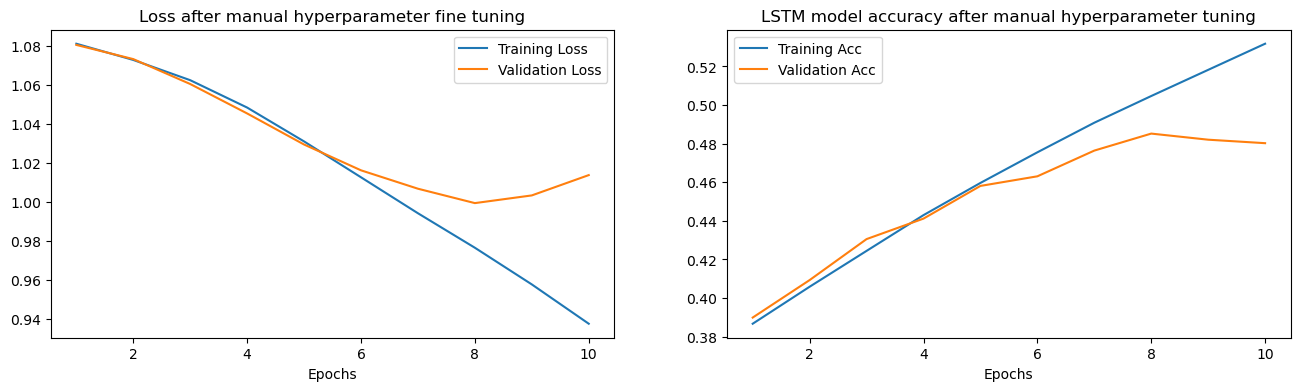

In [97]:
# Plotting the loss on the first subplot
hist_m = model_LSTM_manual_fit.history
fig = plt.figure(figsize = (16, 4))
ax = fig.add_subplot(1, 2, 1)
plt.plot(range(1, num_epochs+1), hist_m['loss'], label='Training Loss')
plt.plot(range(1, num_epochs+1), hist_m['val_loss'], label='Validation Loss')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('Loss after manual hyperparameter fine tuning');

# Plotting the accuracy on the second subplot
ax = fig.add_subplot(1, 2, 2)
plt.plot(range(1, num_epochs+1), hist_m['accuracy'], label='Training Acc')
plt.plot(range(1, num_epochs+1), hist_m['val_accuracy'], label='Validation Acc')
plt.legend()
ax.set_xlabel('Epochs')
ax.set_title('LSTM model accuracy after manual hyperparameter tuning')
plt.show()

As we can see from above, we seem to be in a decent spot, and training it more would like cause more overfitting.

In [98]:
print("Final training accuracy:", hist_m['accuracy'][-1])
print("Final validation accuracy:", hist_m['val_accuracy'][-1])

Final training accuracy: 0.5317690372467041
Final validation accuracy: 0.48023492097854614


In [99]:
# Evaluating the model against X_test and Y_test
model_LSTM_manual.evaluate(X_test_reduced, Y_test)

149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.4765 - loss: 1.0348


[1.018304705619812, 0.4842105209827423]

Evaluating the same model as before but with the PCA-reduced features shows us that the test accuracy is actually worse than before (~0.52 before vs ~0.48 now). This could indicate that even though our PCA components seem to capture most of the variance present in the data before, it's still missing some features that could improve our model. The other thing is that the model isn't really running any faster even with PCA, so there doesn't seem to be much benefit to doing this dimensionality-reduction process.

We could try altering our PCA process to see what we can improve upon, but it does seem like we might as well stick with the features we used previously. In either case, we can still view the confusion matrix to get a deeper dive into our accuracy.

### Plotting a confusion matrix for the test predictions

In [100]:
# Getting Y_test_pred for the model
Y_test_pred = model_LSTM_manual.predict(X_test_reduced)
Y_test_pred = np.argmax(Y_test_pred, axis = 1)

# Getting the confusion matrix using Y_test and Y_test_pred
cf = confusion_matrix(
    Y_test,
    Y_test_pred
)

print('Generating the confusion matrix using confusion_matrix from '
  'sklearn.metrics:')
cf

149/149 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step
Generating the confusion matrix using confusion_matrix from sklearn.metrics:


array([[865, 360, 414],
       [457, 605, 425],
       [409, 385, 830]])

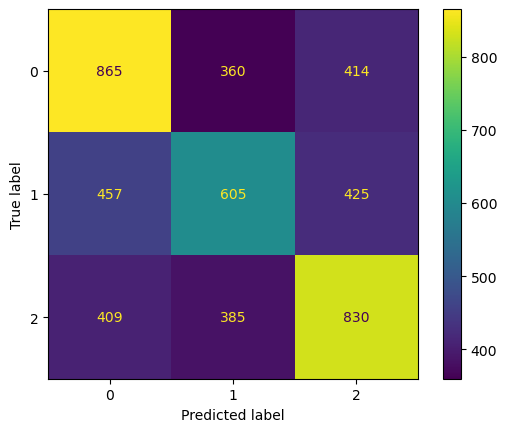

In [101]:
# Plotting the confusion matrix for the model (getting vertical xticks)
disp = ConfusionMatrixDisplay.from_predictions(
    y_true=Y_test,
    y_pred=Y_test_pred,
    labels=None
)

In [102]:
# Getting the precision and recall scores:
precision = sklearn.metrics.precision_score(Y_test, Y_test_pred, average=None)
recall = sklearn.metrics.recall_score(Y_test, Y_test_pred, average=None)

print("Determining precision for each class:")
print(precision, '\n')
print("Determining recall for each class:")
print(recall, '\n')
print("With 2 being positive prediction, 0 being negative, and 1 being neutral.")

Determining precision for each class:
[0.49971115 0.44814815 0.49730377] 

Determining recall for each class:
[0.52776083 0.40685945 0.51108374] 

With 2 being positive prediction, 0 being negative, and 1 being neutral.


Once again, what matters for us is precision (TP / (TP + FP)), as we care about how "right" we are when we predict a certain class. However, we could actualy interpret our results in a slightly different way. Notably, if we lump in class 1 with class 0/2 and say that if we had predicted class 0/2 and the true label were actually 1, it wouldn't necessarily be a bad thing, as it just means we broke even. Therefore, the only time we actually lose money is when the opposite class (0 vs 2) is true.

In other words, based on the matrix above, if our model predicted that we should've entered long (class 2), we would've remained netural 26% of the time (457 / (865 + 457 + 409)), while making money 50% of the time (865 / (865 + 457 + 409)), and losing money 24% of the time (409 / (865 + 457 + 409). Therefore, our accuracy for predicting either a neutral or positive result would be the following:
 - Precision for correctly predicting class 0/1: 76% ((865 + 457) / (865 + 457 + 409))
 - Precision for correctly predicting class 1/2: 75% ((425 + 830) / (414 + 425 + 830))

If we want to consider it the old way, and only compare class 0 with class 2, here are the precision metrics for that:
 - Precision for class 0: 68% (865 / (865 + 409))
 - Precision for class 2: 67% (830 / (414 + 830))

Overall, using PCA doesn't appear to yield any better results (and in fact yielded worse results), and we might be better off sticking with our original features.

## Conclusions for PCA-LSTM Models
Overall, our LSTM model using PCA dimensionality reduction on our features resulted in worse accuracies than not using PCA at all. This is somewhat surprising, as the goal of PCA was to reduce the noise/overfitting, along with making the model run faster. However, both of these might be able to be explained through our model architecture.

Firstly, even though PCA did find the top components that explained ~80% of the variance for our features, there were still 13 components that our model had to run through, so the generalization benefits might not have been as large. Furthermore, because our model included dropout layers, the overfitting issue was already somewhat mitigated even in the first model.

Secondly, in terms of speed, the main bottleneck for LSTM models is primarily in the amount of computation that needs to be done at every LSTM unit. Specifically, the number of LSTM units determines how many parameters need to be tuned, which scales exponentially the more units we have. For example, in our first LSTM layer, with 256 units, we would need a (256 x 256) weight matrix, plus a 1 x 256 bias matrix, all multiplied by 4 (for the 4 LSTM cells) to get from the previous hidden state to the new state, which equates to 263,168 parameters that need to be tuned. Compare that with the number of feature parameters that need to be tuned - (13 x 256) * 4 = 13,312 - and we see that the number of the inner LSTM parameters is an order of magnitude greater. Even with more features (previously we had 32), it would still clearly not make as large of an impact. The other computational bottleneck is with the length of our sequences, as it scales linearly with computation time (since every additional day equates to that much more computation through the LSTM layers). Because there's no way to parallelize that process (since future cells depend on previous cells), our model has to slowly work its way sequentially through all the series.

All in all, due to how LSTMs inherently work, PCA might not be able to improve our model by that much. For us, the benefits of using PCA don't seem to outweigh the tradeoff in accuracy, and we likely won't use this as our final model. Nevertheless, we can check the literature to see if other models out there are more successful.

# Articles that also attempt PCA with LSTM for stock forecast prediction

PCA-LSTM research papers:
 - https://ieeexplore.ieee.org/document/9778913
 - https://dl.acm.org/doi/10.1145/3545839.3545852
 - https://www.ijsmdo.org/articles/smdo/full_html/2023/01/smdo230024/smdo230024.html
 - https://link.springer.com/article/10.1007/s10614-024-10629-x#:~:text=The%20PCA%20method%20is%20utilized,et%20al.%2C%202023)
    - Probably the most detailed one

The articles above seem to use a similar PCA process to the one used here. However, the number of LSTM model layers and node sizes appear to be different in some of the cases. Either way, what's interesting is that some of these articles purport to have better results than traditional LSTM models; however, they (especially the first group of researchers) use inputs like the max or the minimum of the day, skewing results and not presenting an accurate picture of what could happen in reality. I think tuning the current PCA-LSTM models above even more could prove to be interesting, but PCA overall (at least with our current features) doesn't seem to be very promising.

# Next Steps
Overall, we have collectively run dozens of models, only a portion of which have been shown in these notebooks. There are an endless number of things to try, but as we only have so much time to work on this project - and we do want to see an end - we will conclude the model testing here. While PCA looked promising, it seems that our previous model using most of the training data gave us the best accuracies, and we will choose that to be our final model. We will explain our reasoning in a final evaluation notebook, and we will try implementing our findings on new Q1 2025 data.

If we were to continue this project, below are some next steps that we could have taken:
 - Adding more features to see 1) what those features do, and 2) if PCA would perform better with them
 - Implementing an early stopping callback to get the models to not overfit
 - Trying embeddings with sector features
 - Utilizing the functional API for multiple output heads
 - Finish running sliding-window model (which could take over 20+ hours) that keeps previous parameters while training on new train data
 - Integrating sliding-window model across more time frames and seeing the differences in test accuracies
 - With the sliding-window model, getting confusion matrix outputs to track how sub-group accuracies chance across different time frames
 - Try testing with GRUs as well instead of just LSTMs
 - Testing with transformer models